In [1]:
%ls

All_Beauty_Reviews_Filtered_With_Images.jsonl  sample_data/
embeddings_visualization.png


Loaded 200 reviews
Rating distribution: {1: 31, 2: 10, 3: 11, 4: 22, 5: 126}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: LiYuan/amazon-review-sentiment-analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting embeddings (this may take a minute)...
Embeddings shape: (200, 768)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


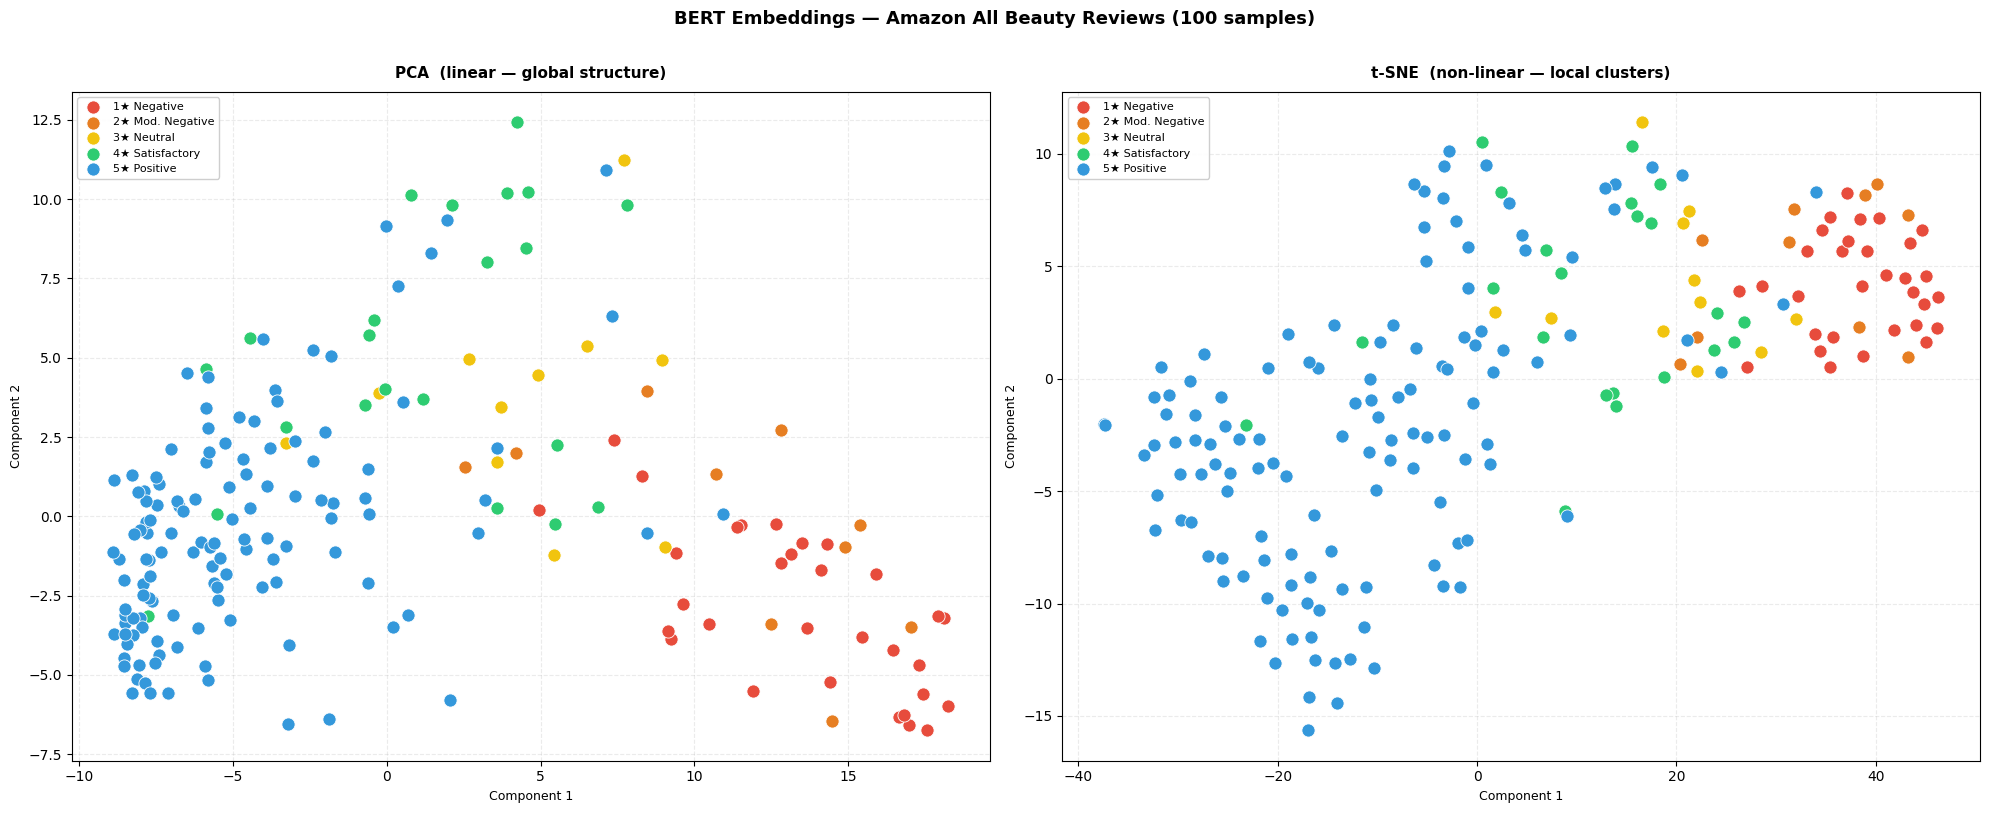

In [1]:
import json
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load reviews from dataset
DATASET_PATH = "All_Beauty_Reviews_Filtered_With_Images.jsonl"
N_SAMPLES    = 200
random.seed(42)

all_reviews = []
with open(DATASET_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            all_reviews.append(json.loads(line))

sampled = random.sample(all_reviews, min(N_SAMPLES, len(all_reviews)))

sentences = []
labels    = []
for entry in sampled:
    text   = entry["text"].replace("<br />", " ").strip()
    rating = max(1, min(5, int(round(float(entry["rating"])))))
    sentences.append(text)
    labels.append(rating)

print(f"Loaded {len(sentences)} reviews")
print(f"Rating distribution: { {r: labels.count(r) for r in range(1,6)} }")

# Declare pretrained model
MODEL_NAME = "LiYuan/amazon-review-sentiment-analysis"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

# Extract embedding vectors
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

print("Extracting embeddings (this may take a minute)...")
embeddings = np.array([get_embedding(s) for s in sentences])
print(f"Embeddings shape: {embeddings.shape}")

# Dimensionality Reduction for 2D visualization
pca_2d  = PCA(n_components=2).fit_transform(embeddings)
tsne_2d = TSNE(n_components=2, perplexity=15, random_state=42, n_iter=1000).fit_transform(embeddings)

# plot config
COLORS = {1:"#e74c3c", 2:"#e67e22", 3:"#f1c40f", 4:"#2ecc71", 5:"#3498db"}
NAMES  = {1:"1★ Negative", 2:"2★ Mod. Negative", 3:"3★ Neutral",
          4:"4★ Satisfactory", 5:"5★ Positive"}

# Scatter plot builder
def build_plot(ax, coords, all_labels, title):
    for star in range(1, 6):
        idx = [i for i, l in enumerate(all_labels) if l == star]
        if not idx:
            continue
        ax.scatter(
            coords[idx, 0], coords[idx, 1],
            c=COLORS[star], label=NAMES[star],
            s=90, edgecolors="white", linewidths=0.6,
            zorder=3,
        )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=8, framealpha=0.95, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlabel("Component 1", fontsize=9)
    ax.set_ylabel("Component 2", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "BERT Embeddings — Amazon All Beauty Reviews (100 samples)",
    fontsize=13, fontweight="bold", y=1.01,
)

build_plot(axes[0], pca_2d,  labels, "PCA  (linear — global structure)")
build_plot(axes[1], tsne_2d, labels, "t-SNE  (non-linear — local clusters)")

plt.tight_layout()
plt.savefig("embeddings_visualization.png", dpi=150, bbox_inches="tight")
plt.show()